In [1]:
# These are our tools — we import them once at the top and use them throughout the project

import pandas as pd       # pandas: loads and manipulates tabular data (our CSV files)
import numpy as np        # numpy: fast math on arrays of numbers
import matplotlib.pyplot as plt  # matplotlib: for plotting graphs
import os                 # os: for interacting with file paths and folders


In [2]:
# pd.read_csv() reads the CSV file from disk into a DataFrame (a table in memory)
# header=None → the file has no column headers on row 1, so we supply them manually
# names=[...] → we name each column ourselves based on what we know about CAN frames

df_dos = pd.read_csv('DoS_dataset.csv', header=None,
                     names=['timestamp', 'can_id', 'dlc',
                            'b0','b1','b2','b3','b4','b5','b6','b7','flag'])

# .head() shows the first 5 rows — just to confirm it loaded correctly
print("=== First 5 rows ===")
print(df_dos.head())

# .shape returns (number of rows, number of columns)
print(f"\nTotal frames: {df_dos.shape[0]}")
print(f"Total columns: {df_dos.shape[1]}")

# value_counts() counts how many times each unique value appears in the 'flag' column
# R = normal frame, T = injected attack frame
print("\nFlag counts (R=normal, T=attack):")
print(df_dos['flag'].value_counts())

=== First 5 rows ===
      timestamp can_id  dlc  b0  b1  b2  b3  b4  b5  b6  b7 flag
0  1.478198e+09   0316    8  05  21  68  09  21  21  00  6f    R
1  1.478198e+09   018f    8  fe  5b  00  00  00  3c  00  00    R
2  1.478198e+09   0260    8  19  21  22  30  08  8e  6d  3a    R
3  1.478198e+09   02a0    8  64  00  9a  1d  97  02  bd  00    R
4  1.478198e+09   0329    8  40  bb  7f  14  11  20  00  14    R

Total frames: 3665771
Total columns: 12

Flag counts (R=normal, T=attack):
flag
R    3047062
T     587521
Name: count, dtype: int64


In [3]:
# We'll load all 4 attack files + the normal file and print a summary of each
# This gives us a complete picture of the dataset before we do any ML

# Define the attack files and their labels
# Each tuple is (filename, attack_type_name)
files = [
    ('DoS_dataset.csv',   'DoS'),
    ('Fuzzy_dataset.csv', 'Fuzzy'),
    ('gear_dataset.csv',  'Gear'),
    ('RPM_dataset.csv',   'RPM'),
]

# Loop through each file
for filename, attack_name in files:
    
    # Load the file into a DataFrame
    df = pd.read_csv(filename, header=None,
                     names=['timestamp','can_id','dlc',
                            'b0','b1','b2','b3','b4','b5','b6','b7','flag'])
    
    # Count R and T frames
    counts = df['flag'].value_counts()
    normal_count = counts.get('R', 0)   # .get() safely returns 0 if 'R' doesn't exist
    attack_count = counts.get('T', 0)
    total = len(df)                      # len() gives the number of rows
    
    # Print a clean summary line for each file
    print(f"[{attack_name}] Total: {total:,} | Normal(R): {normal_count:,} | Attack(T): {attack_count:,}")

[DoS] Total: 3,665,771 | Normal(R): 3,047,062 | Attack(T): 587,521
[Fuzzy] Total: 3,838,860 | Normal(R): 3,259,177 | Attack(T): 491,847
[Gear] Total: 4,443,142 | Normal(R): 3,805,725 | Attack(T): 597,252
[RPM] Total: 4,621,702 | Normal(R): 3,925,329 | Attack(T): 654,897


In [6]:
normal_rows = []

with open('normal_run_data.txt', 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()   # remove \n and leading/trailing spaces
        
        if not line:          # skip empty lines
            continue
        
        try:
            tokens = line.split()   # split by any whitespace into a list of tokens
            
            # tokens[0] = 'Timestamp:'
            # tokens[1] = the actual timestamp value
            # tokens[2] = 'ID:'
            # tokens[3] = the CAN ID
            # tokens[4] = '000'  ← this extra token was causing the failure before
            # tokens[5] = 'DLC:'
            # tokens[6] = the DLC value
            # tokens[7:15] = the 8 payload bytes

            timestamp = float(tokens[1])
            can_id    = tokens[3]
            dlc       = int(tokens[6])
            payload   = tokens[7:15]    # fixed: was 6:14, now 7:15

            while len(payload) < 8:
                payload.append('00')

            row = {
                'timestamp': timestamp,
                'can_id':    can_id,
                'dlc':       dlc,
                'b0': payload[0], 'b1': payload[1],
                'b2': payload[2], 'b3': payload[3],
                'b4': payload[4], 'b5': payload[5],
                'b6': payload[6], 'b7': payload[7],
                'flag': 'R'
            }

            normal_rows.append(row)

        except:
            continue

df_normal = pd.DataFrame(normal_rows)

print(f"Normal run frames loaded: {len(df_normal):,}")
print(df_normal.head())

Normal run frames loaded: 988,871
      timestamp can_id  dlc  b0  b1  b2  b3  b4  b5  b6  b7 flag
0  1.479121e+09   0350    8  05  28  84  66  6d  00  00  a2    R
1  1.479121e+09   02c0    8  14  00  00  00  00  00  00  00    R
2  1.479121e+09   0430    8  00  00  00  00  00  00  00  00    R
3  1.479121e+09   04b1    8  00  00  00  00  00  00  00  00    R
4  1.479121e+09   01f1    8  00  00  00  00  00  00  00  00    R


In [7]:
# ── Step 1: Extract only the ATTACK frames from each attack file ──────────────
# We already have df_dos loaded. Let's reload all 4 cleanly and extract T frames.
# We also extract some R frames from each file for the normal class.

# This dictionary maps each filename to a numeric attack label
# 0 = normal, 1 = DoS, 2 = Fuzzy, 3 = Gear, 4 = RPM
attack_files = {
    'DoS_dataset.csv':   1,
    'Fuzzy_dataset.csv': 2,
    'gear_dataset.csv':  3,
    'RPM_dataset.csv':   4,
}

col_names = ['timestamp','can_id','dlc',
             'b0','b1','b2','b3','b4','b5','b6','b7','flag']

all_attacks = []   # list to collect attack frames from all files

for filename, label in attack_files.items():
    
    print(f"Loading {filename}...")
    
    # load the full file
    df = pd.read_csv(filename, header=None, names=col_names)
    
    # keep only the attack frames (flag == 'T')
    df_attack = df[df['flag'] == 'T'].copy()
    
    # assign the numeric label for this attack type
    # we add a new column called 'label' to track what class each frame belongs to
    df_attack['label'] = label
    
    all_attacks.append(df_attack)
    print(f"  → {len(df_attack):,} attack frames extracted")

# pd.concat() stacks multiple DataFrames vertically into one big DataFrame
df_attacks_combined = pd.concat(all_attacks, ignore_index=True)
# ignore_index=True resets the row numbers from 0 so they don't overlap

print(f"\nTotal attack frames: {len(df_attacks_combined):,}")

Loading DoS_dataset.csv...
  → 587,521 attack frames extracted
Loading Fuzzy_dataset.csv...
  → 491,847 attack frames extracted
Loading gear_dataset.csv...
  → 597,252 attack frames extracted
Loading RPM_dataset.csv...
  → 654,897 attack frames extracted

Total attack frames: 2,331,517


In [8]:
# ── Step 2: Prepare the normal frames ─────────────────────────────────────────

# We have two sources of normal frames:
# 1. df_normal → from normal_run_data.txt (988,871 frames, pure clean traffic)
# 2. R frames inside each attack file → but we already discarded them above

# For now df_normal is our normal class. Let's assign it label 0.

df_normal['label'] = 0   # 0 = normal

print(f"Normal frames available: {len(df_normal):,}")

# ── Step 3: Combine everything into one DataFrame ─────────────────────────────

# Stack normal frames on top of attack frames into one big table
df_all = pd.concat([df_normal, df_attacks_combined], ignore_index=True)

print(f"Total combined frames: {len(df_all):,}")

# Check the label distribution — how many frames per class
print("\nFrames per class:")
label_names = {0:'Normal', 1:'DoS', 2:'Fuzzy', 3:'Gear', 4:'RPM'}

for label, name in label_names.items():
    count = len(df_all[df_all['label'] == label])   # filter rows by label value
    print(f"  {name:8s} (label={label}): {count:>10,}")
    

Normal frames available: 988,871
Total combined frames: 3,320,388

Frames per class:
  Normal   (label=0):    988,871
  DoS      (label=1):    587,521
  Fuzzy    (label=2):    491,847
  Gear     (label=3):    597,252
  RPM      (label=4):    654,897


In [9]:
# ── Feature Engineering ───────────────────────────────────────────────────────
# Raw CAN frames are not directly useful for an ML model as-is.
# The model doesn't understand hex strings like '0316' or '8a'.
# We need to convert each frame into a set of NUMBERS that capture meaningful patterns.

# Here are the features we'll extract from each frame:
#
# 1. can_id_int      → CAN ID converted from hex string to integer
#                      e.g. '0316' → 790
#                      Why: DoS always uses ID 0x000, spoofing uses specific IDs
#
# 2. dlc             → Data Length Code (already a number, just keep it)
#                      Why: some attacks use unusual DLC values
#
# 3. b0..b7 as int   → each payload byte converted from hex string to integer
#                      e.g. 'ff' → 255, '00' → 0
#                      Why: fuzzy attacks use random byte values, spoofing uses specific ones
#
# 4. inter_arrival   → time gap between this frame and the previous frame
#                      Why: DoS attacks send frames extremely fast → tiny gaps
#                      This is the MOST important feature for DoS detection

# First convert can_id from hex string to integer
# int(x, 16) converts a hex string to decimal integer
# errors='coerce' turns any bad values into NaN instead of crashing
df_all['can_id_int'] = df_all['can_id'].apply(lambda x: int(str(x), 16))
# lambda x: ... is a small one-line function — for each value x, apply int(x, 16)

print("CAN ID converted. Sample:")
print(df_all[['can_id', 'can_id_int']].head())

CAN ID converted. Sample:
  can_id  can_id_int
0   0350         848
1   02c0         704
2   0430        1072
3   04b1        1201
4   01f1         497


In [10]:
# ── Convert payload bytes from hex strings to integers ────────────────────────

byte_cols = ['b0','b1','b2','b3','b4','b5','b6','b7']

for col in byte_cols:
    # int(x, 16) converts hex string to integer
    # errors='coerce' converts any invalid values to NaN instead of crashing
    df_all[col] = df_all[col].apply(lambda x: int(str(x), 16))

print("Payload bytes converted. Sample:")
print(df_all[['b0','b1','b2','b3','b4','b5','b6','b7']].head())

Payload bytes converted. Sample:
   b0  b1   b2   b3   b4  b5  b6   b7
0   5  40  132  102  109   0   0  162
1  20   0    0    0    0   0   0    0
2   0   0    0    0    0   0   0    0
3   0   0    0    0    0   0   0    0
4   0   0    0    0    0   0   0    0


In [11]:
# ── Compute inter-arrival time ─────────────────────────────────────────────────
# Inter-arrival time = the time gap between consecutive frames on the bus
# This is the single most powerful feature for detecting DoS attacks
# because DoS floods the bus with frames at an abnormally high rate
# meaning the time gap between frames becomes extremely small

# .diff() computes the difference between each row and the row before it
# e.g. if row 0 timestamp = 1.000 and row 1 timestamp = 1.005
# then inter_arrival for row 1 = 0.005 seconds
df_all['inter_arrival'] = df_all['timestamp'].diff()

# The very first row has no previous row to subtract from
# so diff() gives NaN (Not a Number) for row 0
# we fill that NaN with 0
df_all['inter_arrival'] = df_all['inter_arrival'].fillna(0)

# Clip negative values to 0
# Negative inter-arrival can happen at the boundary between files
# e.g. last timestamp of normal file > first timestamp of DoS file
# that's an artifact of how we concatenated, not real data
df_all['inter_arrival'] = df_all['inter_arrival'].clip(lower=0)

print("Inter-arrival time computed. Sample:")
print(df_all[['timestamp', 'inter_arrival']].head(10))

print(f"\nMin inter-arrival: {df_all['inter_arrival'].min():.6f} seconds")
print(f"Max inter-arrival: {df_all['inter_arrival'].max():.6f} seconds")
print(f"Mean inter-arrival: {df_all['inter_arrival'].mean():.6f} seconds")

Inter-arrival time computed. Sample:
      timestamp  inter_arrival
0  1.479121e+09       0.000000
1  1.479121e+09       0.000221
2  1.479121e+09       0.000554
3  1.479121e+09       0.000238
4  1.479121e+09       0.000248
5  1.479121e+09       0.000248
6  1.479121e+09       0.000252
7  1.479121e+09       0.000239
8  1.479121e+09       0.000241
9  1.479121e+09       0.000244

Min inter-arrival: 0.000000 seconds
Max inter-arrival: 3.163033 seconds
Mean inter-arrival: 0.002744 seconds


In [12]:
# ── Build the final feature matrix ────────────────────────────────────────────
# We select only the columns that will be fed into the model
# These are called "features" — the input the model learns from

feature_cols = [
    'can_id_int',      # CAN ID as integer
    'dlc',             # data length code
    'b0','b1','b2','b3','b4','b5','b6','b7',  # 8 payload bytes
    'inter_arrival'    # time gap between frames
]

# X = the feature matrix (input to the model)
# Every row is one CAN frame, every column is one feature
# Shape will be (3,320,388 rows × 12 columns)
X = df_all[feature_cols].values
# .values converts the DataFrame into a raw numpy array
# numpy arrays are what the model actually works with — faster than DataFrames

# y = the label vector (what the model is trying to predict)
# Every row is one number: 0=Normal, 1=DoS, 2=Fuzzy, 3=Gear, 4=RPM
y = df_all['label'].values

print(f"Feature matrix shape: {X.shape}")
print(f"Label vector shape:   {y.shape}")
print(f"\nFeature columns: {feature_cols}")
print(f"\nFirst row of X: {X[0]}")
print(f"First label:    {y[0]}")

Feature matrix shape: (3320388, 11)
Label vector shape:   (3320388,)

Feature columns: ['can_id_int', 'dlc', 'b0', 'b1', 'b2', 'b3', 'b4', 'b5', 'b6', 'b7', 'inter_arrival']

First row of X: [848.   8.   5.  40. 132. 102. 109.   0.   0. 162.   0.]
First label:    0


In [13]:
# ── Balance the classes ────────────────────────────────────────────────────────
# Right now we have unequal numbers per class:
# Normal:  988,871
# DoS:     587,521
# Fuzzy:   491,847  ← smallest attack class
# Gear:    597,252
# RPM:     654,897

# We'll undersample — reduce every class down to match the smallest class (Fuzzy)
# This way the model sees equal amounts of each class during training
# and doesn't get biased toward predicting "Normal" just because it has more frames

from sklearn.utils import resample   # resample() randomly samples rows from a DataFrame

# Find the size of the smallest class
# np.bincount() counts how many times each label (0,1,2,3,4) appears in y
class_counts = np.bincount(y)
min_count = class_counts.min()   # smallest class size

print(f"Class counts before balancing: {class_counts}")
print(f"We will downsample everything to: {min_count:,} frames per class")

X_balanced = []   # will hold balanced feature rows
y_balanced = []   # will hold balanced labels

for label in range(5):   # loop through labels 0, 1, 2, 3, 4
    
    # get all rows belonging to this class
    X_class = X[y == label]   # boolean indexing — keep only rows where y equals label
    y_class = y[y == label]
    
    # randomly downsample to min_count rows
    # replace=False means we don't pick the same row twice
    # random_state=42 makes it reproducible — same result every time you run it
    X_resampled, y_resampled = resample(X_class, y_class,
                                         n_samples=min_count,
                                         replace=False,
                                         random_state=42)
    
    X_balanced.append(X_resampled)
    y_balanced.append(y_resampled)

# stack all classes back into one array
X_balanced = np.vstack(X_balanced)   # vstack stacks arrays vertically (row by row)
y_balanced = np.concatenate(y_balanced)   # concatenate joins 1D arrays end to end

print(f"\nClass counts after balancing: {np.bincount(y_balanced)}")
print(f"Total frames after balancing: {len(X_balanced):,}")

Class counts before balancing: [988871 587521 491847 597252 654897]
We will downsample everything to: 491,847 frames per class

Class counts after balancing: [491847 491847 491847 491847 491847]
Total frames after balancing: 2,459,235


In [14]:
# ── Scale the features ─────────────────────────────────────────────────────────
# Right now our features have very different ranges:
# can_id_int   → 0 to 2047      (11-bit CAN ID max)
# dlc          → 0 to 8
# b0..b7       → 0 to 255
# inter_arrival → 0.0 to 3.16   (seconds)

# This is a problem because the model uses math (multiplication, addition)
# A feature with range 0-2047 will dominate a feature with range 0-3.16
# The model would pay too much attention to can_id and ignore inter_arrival

# Solution: StandardScaler — transforms every feature to have:
# mean = 0 and standard deviation = 1
# so all features are on the same scale and equally important to the model

# Think of it like converting temperatures:
# 100°F and 37.7°C are the same value — just on the same scale now

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()   # create the scaler object

# fit_transform() does two things in one step:
# 1. fit   → computes the mean and std of each feature column
# 2. transform → applies the scaling formula: (value - mean) / std
X_scaled = scaler.fit_transform(X_balanced)

print("Scaling done.")
print(f"Feature matrix shape: {X_scaled.shape}")
print(f"\nBefore scaling - can_id_int range: {X_balanced[:,0].min():.1f} to {X_balanced[:,0].max():.1f}")
print(f"After scaling  - can_id_int range: {X_scaled[:,0].min():.3f} to {X_scaled[:,0].max():.3f}")
print(f"\nBefore scaling - inter_arrival range: {X_balanced[:,10].min():.4f} to {X_balanced[:,10].max():.4f}")
print(f"After scaling  - inter_arrival range: {X_scaled[:,10].min():.3f} to {X_scaled[:,10].max():.3f}")

Scaling done.
Feature matrix shape: (2459235, 11)

Before scaling - can_id_int range: 0.0 to 2047.0
After scaling  - can_id_int range: -1.450 to 2.670

Before scaling - inter_arrival range: 0.0000 to 3.1630
After scaling  - inter_arrival range: -0.051 to 51.308


In [15]:
# ── Train / Test Split ─────────────────────────────────────────────────────────
# We split our data into two sets:
# Training set (80%) → the model learns from this
# Test set     (20%) → we evaluate the model on this AFTER training
#
# The model never sees the test set during training
# So the test result tells us how well it generalises to new unseen data
# This is exactly how it will behave on the STM32 — seeing frames it never saw before

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,       # our feature matrix
    y_balanced,     # our labels
    test_size=0.2,          # 20% goes to test set
    random_state=42,        # fixed seed → same split every time
    stratify=y_balanced     # ensures each class has 80/20 split proportionally
                            # without this, test set might have unequal class distribution
)

print(f"Training samples: {len(X_train):,}")
print(f"Test samples:     {len(X_test):,}")
print(f"\nTraining class distribution: {np.bincount(y_train)}")
print(f"Test class distribution:     {np.bincount(y_test)}")

Training samples: 1,967,388
Test samples:     491,847

Training class distribution: [393477 393478 393478 393477 393478]
Test class distribution:     [98370 98369 98369 98370 98369]


In [16]:
# ── Build the MLP model ────────────────────────────────────────────────────────
# MLP = Multi Layer Perceptron — a simple neural network
# It's the same architecture you used in your thesis for fall detection
#
# Our network structure:
#
#  Input layer:   11 neurons  (one per feature)
#       ↓
#  Hidden layer 1: 64 neurons  (learns basic patterns)
#       ↓
#  Hidden layer 2: 32 neurons  (learns more complex combinations)
#       ↓
#  Output layer:   5 neurons   (one per class: Normal/DoS/Fuzzy/Gear/RPM)
#
# We keep it small deliberately — it needs to fit on the STM32 later

import tensorflow as tf
from tensorflow import keras

# Sequential means layers are stacked one after another in sequence
model = keras.Sequential([
    
    # Input layer — tells the model to expect 11 features per sample
    keras.layers.Input(shape=(11,)),
    
    # First hidden layer
    # 64 = number of neurons
    # activation='relu' → ReLU function: output = max(0, x)
    # ReLU kills negative values and passes positive ones through
    # This lets the network learn non-linear patterns
    keras.layers.Dense(64, activation='relu'),
    
    # Dropout layer — randomly switches off 20% of neurons during training
    # This prevents overfitting (memorising training data instead of learning patterns)
    keras.layers.Dropout(0.2),
    
    # Second hidden layer — smaller, refines what layer 1 learned
    keras.layers.Dense(32, activation='relu'),
    
    keras.layers.Dropout(0.2),
    
    # Output layer — 5 neurons, one per class
    # activation='softmax' converts raw scores into probabilities that sum to 1
    # e.g. [0.02, 0.91, 0.03, 0.02, 0.02] → model is 91% confident this is DoS
    keras.layers.Dense(5, activation='softmax')
])

# Print a summary of the model — shows layers, shapes, and parameter count
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │             768 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 5)                   │             165 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,013 (11.77 KB)

 Trainable params: 3,013 (11.77 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
# ── Compile the model ──────────────────────────────────────────────────────────
# Compiling sets up the training configuration — how the model learns

model.compile(
    # optimizer='adam' → Adam is the algorithm that adjusts weights during training
    # It's the most popular optimizer — works well without much tuning
    optimizer='adam',
    
    # loss='sparse_categorical_crossentropy' → the error function
    # It measures how wrong the model's predictions are
    # 'sparse' means our labels are integers (0,1,2,3,4) not one-hot encoded
    # The optimizer tries to minimise this loss during training
    loss='sparse_categorical_crossentropy',
    
    # metrics=['accuracy'] → what we want to monitor during training
    # Accuracy = percentage of frames classified correctly
    metrics=['accuracy']
)

# ── Train the model ────────────────────────────────────────────────────────────
history = model.fit(
    X_train, y_train,       # training data and labels
    epochs=10,              # number of times the model sees the full training set
                            # each pass through = one epoch
    batch_size=1024,        # process 1024 frames at a time before updating weights
                            # larger batch = faster training on large datasets
    validation_split=0.1,  # use 10% of training data to monitor validation accuracy
                            # this checks for overfitting during training
    verbose=1               # print progress for each epoch
)

print("\nTraining complete!")

Epoch 1/10
1730/1730 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.9693 - loss: 0.1099 - val_accuracy: 0.9930 - val_loss: 0.0239
Epoch 2/10
1730/1730 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9919 - loss: 0.0302 - val_accuracy: 0.9959 - val_loss: 0.0142
Epoch 3/10
1730/1730 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9945 - loss: 0.0190 - val_accuracy: 0.9978 - val_loss: 0.0073
Epoch 4/10
1730/1730 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9963 - loss: 0.0126 - val_accuracy: 0.9985 - val_loss: 0.0050
Epoch 5/10
1730/1730 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9971 - loss: 0.0100 - val_accuracy: 0.9986 - val_loss: 0.0042
Epoch 6/10
1730/1730 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9976 - loss: 0.0083 - val_accuracy: 0.9991 - val_loss: 0.0032
Epoch 7/10
1730/1730 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9979 - loss: 0.0073 - val_accuracy: 0.9992 - val_loss: 0.0029
Epoch 8/10
1730/1730 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9981 - loss: 0

Test Accuracy: 99.92%
Test Loss:     0.0028


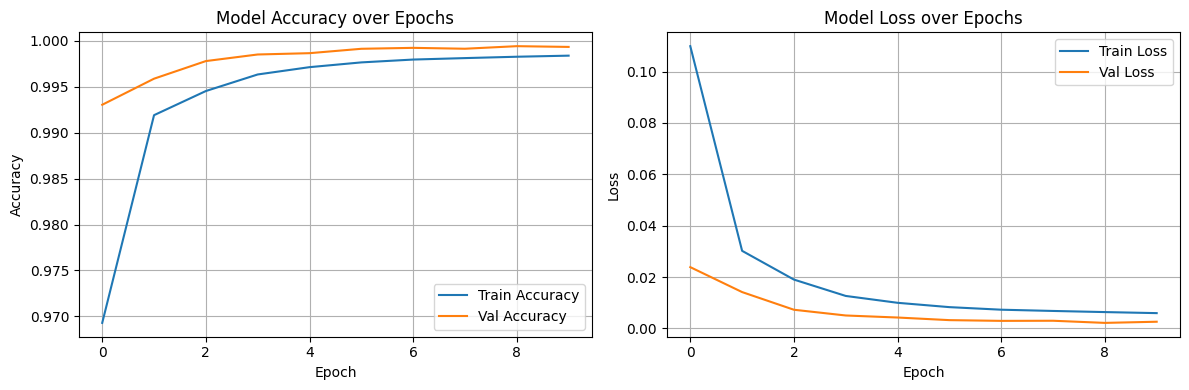

In [18]:
# ── Evaluate on the test set ───────────────────────────────────────────────────
# This is the real performance check — data the model has never seen at all
# not even during validation

test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss:     {test_loss:.4f}")

# ── Plot training history ──────────────────────────────────────────────────────
# Visualise how accuracy and loss changed across epochs

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
# fig = the whole figure
# ax1, ax2 = two side by side plots

# Plot accuracy
ax1.plot(history.history['accuracy'], label='Train Accuracy')
ax1.plot(history.history['val_accuracy'], label='Val Accuracy')
ax1.set_title('Model Accuracy over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()   # shows the label names on the plot
ax1.grid(True) # adds grid lines for readability

# Plot loss
ax2.plot(history.history['loss'], label='Train Loss')
ax2.plot(history.history['val_loss'], label='Val Loss')
ax2.set_title('Model Loss over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()   # prevents plots from overlapping
plt.show()

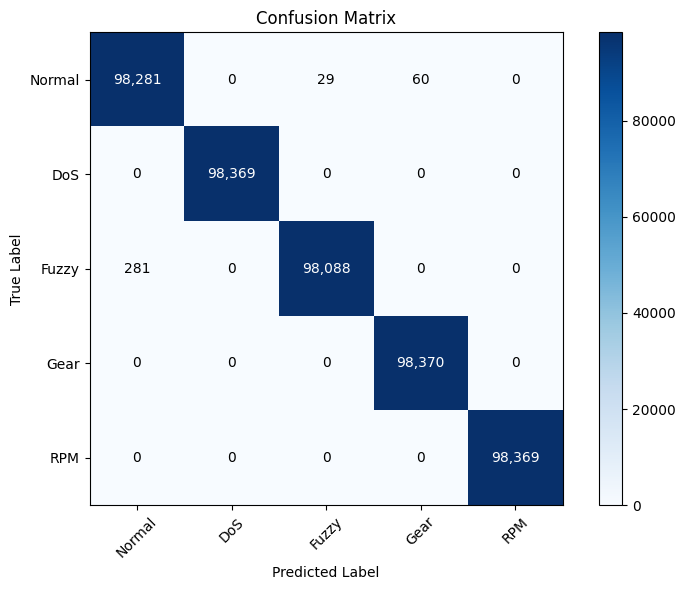


Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     98370
         DoS       1.00      1.00      1.00     98369
       Fuzzy       1.00      1.00      1.00     98369
        Gear       1.00      1.00      1.00     98370
         RPM       1.00      1.00      1.00     98369

    accuracy                           1.00    491847
   macro avg       1.00      1.00      1.00    491847
weighted avg       1.00      1.00      1.00    491847



In [19]:
# ── Confusion Matrix ───────────────────────────────────────────────────────────
# A confusion matrix shows exactly which classes the model confuses with each other
# Rows = actual class, Columns = predicted class
# Perfect model = all numbers on the diagonal, zeros everywhere else

from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import numpy as np

# Generate predictions on the test set
# model.predict() returns probabilities for each class per frame
# e.g. [0.01, 0.97, 0.01, 0.00, 0.01] → predicted class = 1 (DoS)
y_pred_probs = model.predict(X_test, verbose=0)

# np.argmax() picks the index of the highest probability = predicted class
y_pred = np.argmax(y_pred_probs, axis=1)
# axis=1 means argmax across columns (per row), not across all values

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot it as a heatmap
class_names = ['Normal', 'DoS', 'Fuzzy', 'Gear', 'RPM']

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
# imshow displays a 2D array as a coloured image
# cmap='Blues' = blue colour scale, darker = higher number
plt.colorbar(im)

# Add axis labels
ax.set_xticks(range(5))
ax.set_yticks(range(5))
ax.set_xticklabels(class_names, rotation=45)
ax.set_yticklabels(class_names)
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('Confusion Matrix')

# Add numbers inside each cell
for i in range(5):
    for j in range(5):
        # choose white or black text depending on cell darkness
        color = 'white' if cm[i,j] > cm.max()/2 else 'black'
        ax.text(j, i, f'{cm[i,j]:,}', ha='center', va='center', color=color)

plt.tight_layout()
plt.show()

# Print detailed per-class metrics
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

In [20]:
# ── Save the trained model ─────────────────────────────────────────────────────
# We save it in two formats:
# 1. Keras native format (.keras) → for reloading in Python later
# 2. TFLite format → for deployment on STM32

# Save Keras model — useful if you want to retrain or fine-tune later
model.save('can_ids_model.keras')
print("Keras model saved: can_ids_model.keras")

# ── Convert to TFLite with int8 quantization ───────────────────────────────────

# A representative dataset is required for full integer quantization
# The converter uses it to measure the range of activations in each layer
# so it knows how to map float32 values to int8 values accurately
# We use a random sample of 1000 training frames for this

def representative_dataset():
    # take 1000 random samples from training data
    indices = np.random.choice(len(X_train), 1000, replace=False)
    for i in indices:
        # yield feeds one sample at a time to the converter
        # shape must be (1, 11) — batch size of 1, 11 features
        sample = X_train[i].reshape(1, 11).astype(np.float32)
        yield [sample]

# Create a TFLite converter from our trained Keras model
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# Tell the converter to optimise for size (triggers quantization)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Provide the representative dataset so it can do full int8 quantization
converter.representative_dataset = representative_dataset

# Force all ops (operations) to use int8
# This ensures the model runs fully in integer math on the STM32
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]

# Force input and output tensors to also be int8 (not just internal layers)
converter.inference_input_type  = tf.int8
converter.inference_output_type = tf.int8

# Run the conversion
tflite_model = converter.convert()

# Save the .tflite file to disk
with open('can_ids_model.tflite', 'wb') as f:
    f.write(tflite_model)

print(f"TFLite int8 model saved: can_ids_model.tflite")
print(f"Float32 model size: {len(model.get_weights()[0].tobytes()) * 8 / 1024:.1f} KB (weights only)")
print(f"TFLite int8 model size: {len(tflite_model) / 1024:.2f} KB")

Keras model saved: can_ids_model.keras
INFO:tensorflow:Assets written to: C:\Users\MSI\AppData\Local\Temp\tmp_cb59mm7\assets


INFO:tensorflow:Assets written to: C:\Users\MSI\AppData\Local\Temp\tmp_cb59mm7\assets


Saved artifact at 'C:\Users\MSI\AppData\Local\Temp\tmp_cb59mm7'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 11), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  2064397292880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2064397294224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2064397293840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2064397293264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2064397293648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2064397294992: TensorSpec(shape=(), dtype=tf.resource, name=None)


C:\Users\MSI\AppData\Local\Programs\Python\Python312\Lib\site-packages\tensorflow\lite\python\convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


TFLite int8 model saved: can_ids_model.tflite
Float32 model size: 22.0 KB (weights only)
TFLite int8 model size: 8.06 KB


In [21]:
# ── Convert .tflite to C array ─────────────────────────────────────────────────
# The STM32 can't read files from disk — it has no filesystem
# Instead we embed the model as a C byte array directly in flash memory
# This is the standard way to deploy TFLite Micro models on MCUs
#
# Normally you'd use the 'xxd' command line tool for this
# But since we're on Windows we'll do it directly in Python

# Read the .tflite binary file
with open('can_ids_model.tflite', 'rb') as f:
    tflite_bytes = f.read()   # rb = read binary mode

# Build the C header file content
c_array = '// Auto-generated model data\n'
c_array += '// DO NOT EDIT MANUALLY\n\n'
c_array += '#ifndef CAN_IDS_MODEL_H\n'
c_array += '#define CAN_IDS_MODEL_H\n\n'
c_array += '#include <stdint.h>\n\n'

# Write the array length as a constant
c_array += f'#define CAN_IDS_MODEL_LEN {len(tflite_bytes)}\n\n'

# Write the array — each byte of the model becomes a hex value in the array
# e.g. 0x1c, 0x00, 0x00, 0x00, ...
c_array += 'alignas(8) const uint8_t can_ids_model_data[] = {\n'

# Loop through every byte and format it as hex
for i, byte in enumerate(tflite_bytes):
    if i % 12 == 0:
        c_array += '  '          # indent every new line
    c_array += f'0x{byte:02x},'  # format byte as hex e.g. 0x1c
    if (i + 1) % 12 == 0:
        c_array += '\n'          # newline every 12 bytes for readability
    else:
        c_array += ' '

c_array += '\n};\n\n'
c_array += '#endif // CAN_IDS_MODEL_H\n'

# Save the header file
with open('can_ids_model.h', 'w') as f:
    f.write(c_array)

print(f"C header file saved: can_ids_model.h")
print(f"Model size: {len(tflite_bytes)} bytes ({len(tflite_bytes)/1024:.2f} KB)")
print(f"\nFirst few bytes of the array:")
print(', '.join([f'0x{b:02x}' for b in tflite_bytes[:12]]))

C header file saved: can_ids_model.h
Model size: 8256 bytes (8.06 KB)

First few bytes of the array:
0x20, 0x00, 0x00, 0x00, 0x54, 0x46, 0x4c, 0x33, 0x00, 0x00, 0x00, 0x00


In [22]:
# ── Save the scaler parameters ─────────────────────────────────────────────────
# The StandardScaler computed a mean and std for each of our 11 features
# We need these exact values hardcoded in the STM32 firmware
# so it can scale incoming frames the same way we scaled training data

import json

# scaler.mean_ → array of 11 mean values (one per feature)
# scaler.scale_ → array of 11 std values (one per feature)

scaler_params = {
    'mean': scaler.mean_.tolist(),    # .tolist() converts numpy array to plain Python list
    'scale': scaler.scale_.tolist()   # so json can serialize it
}

# Save as JSON for reference
with open('scaler_params.json', 'w') as f:
    json.dump(scaler_params, f, indent=2)

print("Scaler parameters saved: scaler_params.json")
print(f"\nFeature means:")
for i, (name, mean) in enumerate(zip(feature_cols, scaler.mean_)):
    print(f"  {name:15s}: {mean:.6f}")

print(f"\nFeature scales (std):")
for i, (name, scale) in enumerate(zip(feature_cols, scaler.scale_)):
    print(f"  {name:15s}: {scale:.6f}")

Scaler parameters saved: scaler_params.json

Feature means:
  can_id_int     : 720.494676
  dlc            : 7.957059
  b0             : 54.488674
  b1             : 58.878468
  b2             : 59.843296
  b3             : 140.869133
  b4             : 67.392157
  b5             : 44.662513
  b6             : 30.610555
  b7             : 86.297398
  inter_arrival  : 0.003127

Feature scales (std):
  can_id_int     : 496.743112
  dlc            : 0.404682
  b0             : 72.945047
  b1             : 61.348985
  b2             : 62.606099
  b3             : 114.584493
  b4             : 68.544737
  b5             : 66.871259
  b6             : 64.732805
  b7             : 106.618242
  inter_arrival  : 0.061588
